<a href="https://colab.research.google.com/github/sethpulgar/challenge-alura-store/blob/main/ChallengeTelecomX2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color='dark'>**Challenge Telecom X2**</h1>

### Extracción del Archivo Tratado

Descripción

Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

In [221]:
import pandas as pd
import numpy as np
datos = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
datos = pd.json_normalize(datos.to_dict(orient='records'))
display(datos.head())

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [222]:
datos['Churn'] = datos['Churn'].replace({'No': 0,'Yes':1,'':1})
datos.shape

(7267, 21)

In [223]:
datos = datos.drop(columns=['phone.MultipleLines'])

In [224]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   int64  
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   internet.InternetService   7267 non-null   object 
 9   internet.OnlineSecurity    7267 non-null   object 
 10  internet.OnlineBackup      7267 non-null   object 
 11  internet.DeviceProtection  7267 non-null   object 
 12  internet.TechSupport       7267 non-null   object 
 13  internet.StreamingTV       7267 non-null   objec

In [225]:
datos['phone.PhoneService'] = datos['phone.PhoneService'].replace({'No': 0,'Yes':1,'':1})
datos['internet.OnlineBackup'] = datos['internet.OnlineBackup'].replace({'No': 0,'Yes':1,'':1})
datos['internet.DeviceProtection'] = datos['internet.DeviceProtection'].replace({'No': 0,'Yes':1,'':1})
datos['internet.TechSupport'] = datos['internet.TechSupport'].replace({'No': 0,'Yes':1,'':1})
datos['internet.StreamingTV'] = datos['internet.StreamingTV'].replace({'No': 0,'Yes':1,'':1})
datos['internet.StreamingMovies'] = datos['internet.StreamingMovies'].replace({'No': 0,'Yes':1,'':1})
datos['internet.OnlineSecurity'] = datos['internet.OnlineSecurity'].replace({'No': 0,'Yes':1,'':1})
datos['account.Charges.Total'] = pd.to_numeric(datos['account.Charges.Total'], errors='coerce')
datos['account.Charges.Monthly'] = pd.to_numeric(datos['account.Charges.Monthly'], errors='coerce')
import warnings
warnings.filterwarnings('ignore')

In [226]:
datos['internet.OnlineSecurity'] = pd.to_numeric(datos['internet.OnlineSecurity'], errors='coerce')
datos['internet.OnlineBackup'] = pd.to_numeric(datos['internet.OnlineBackup'], errors='coerce')
datos['internet.DeviceProtection'] = pd.to_numeric(datos['internet.DeviceProtection'], errors='coerce')
datos['internet.TechSupport'] = pd.to_numeric(datos['internet.TechSupport'], errors='coerce')
datos['internet.StreamingTV'] = pd.to_numeric(datos['internet.StreamingTV'], errors='coerce')
datos['internet.StreamingMovies'] = pd.to_numeric(datos['internet.StreamingMovies'], errors='coerce')
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   int64  
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   int64  
 8   internet.InternetService   7267 non-null   object 
 9   internet.OnlineSecurity    5686 non-null   float64
 10  internet.OnlineBackup      5686 non-null   float64
 11  internet.DeviceProtection  5686 non-null   float64
 12  internet.TechSupport       5686 non-null   float64
 13  internet.StreamingTV       5686 non-null   float

###Eliminación de Columnas Irrelevantes


Descripción

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [227]:
datos.fillna(0, inplace=True)

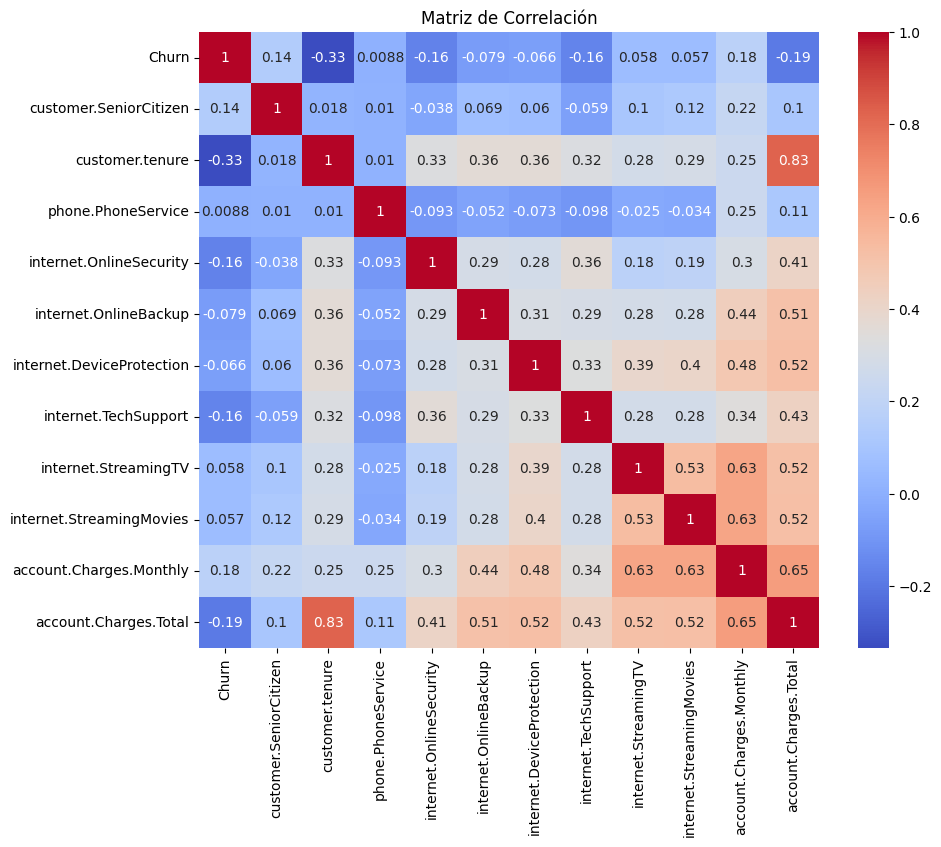

In [228]:
datos_numericos = datos.select_dtypes(include=np.number)
correlacion = datos_numericos.corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

In [229]:
datos = datos.drop(columns=['account.Charges.Total'])
datos = datos.drop(columns=['internet.StreamingMovies'])
datos = datos.drop(columns=['internet.DeviceProtection'])

In [230]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customerID                7267 non-null   object 
 1   Churn                     7267 non-null   int64  
 2   customer.gender           7267 non-null   object 
 3   customer.SeniorCitizen    7267 non-null   int64  
 4   customer.Partner          7267 non-null   object 
 5   customer.Dependents       7267 non-null   object 
 6   customer.tenure           7267 non-null   int64  
 7   phone.PhoneService        7267 non-null   int64  
 8   internet.InternetService  7267 non-null   object 
 9   internet.OnlineSecurity   7267 non-null   float64
 10  internet.OnlineBackup     7267 non-null   float64
 11  internet.TechSupport      7267 non-null   float64
 12  internet.StreamingTV      7267 non-null   float64
 13  account.Contract          7267 non-null   object 
 14  account.

###Encoding

Descripción

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder

In [231]:
#OneHotEncoder
categorical_cols = ['customer.gender', 'customer.Partner', 'customer.Dependents', 'internet.InternetService', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']
datos_encoded = pd.get_dummies(data=datos.drop(columns=['customerID']), columns=categorical_cols, drop_first=True)
display(datos_encoded.head())

,Churn,customer.SeniorCitizen,customer.tenure,phone.PhoneService,internet.OnlineSecurity,internet.OnlineBackup,internet.TechSupport,internet.StreamingTV,account.Charges.Monthly,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,internet.InternetService_Fiber optic,internet.InternetService_No,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,1,0.0,1.0,1.0,1.0,65.6,False,True,True,False,False,True,False,True,False,False,True
1,0,0,9,1,0.0,0.0,0.0,0.0,59.9,True,False,False,False,False,False,False,False,False,False,True
2,1,0,4,1,0.0,0.0,0.0,0.0,73.9,True,False,False,True,False,False,False,True,False,True,False
3,1,1,13,1,0.0,1.0,0.0,1.0,98.0,True,True,False,True,False,False,False,True,False,True,False
4,1,1,3,1,0.0,0.0,1.0,1.0,83.9,False,True,False,True,False,False,False,True,False,False,True


### Verificación de la Proporción de Cancelación (Churn)

Descripción

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

In [232]:
len(datos[datos['Churn'] == 1])

2093

In [233]:
datos['Churn'].value_counts()

,count
Churn,
0,5174
1,2093


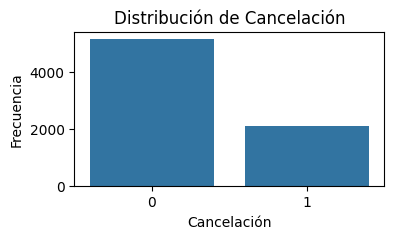

In [234]:
plt.figure(figsize=(4, 2))
sns.countplot(x='Churn', data=datos)
plt.title('Distribución de Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Frecuencia')
plt.show()

###Balanceo de Clases (opcional)

Descripción

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

🔎 Sugerencia:

Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:
Artículo en Alura sobre desbalanceo de datos

In [235]:
from re import X
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
X = datos_encoded.drop('Churn', axis=1)
y = datos_encoded['Churn']

In [236]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [237]:
#Baseline
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier()
dummy.fit(X_train, y_train)

dummy.score(X_test, y_test)

0.7121629058888277

In [238]:
y.value_counts(normalize=True)

,proportion
Churn,
0,0.711986
1,0.288014


In [239]:
oversampling = SMOTE()
X_balanceada,y_balanceada = oversampling.fit_resample(X_train, y_train)

In [240]:
y_balanceada.value_counts(normalize=True)

,proportion
Churn,
0,0.5
1,0.5


### Normalización o Estandarización (si es necesario)

Descripción

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

🔎 Sugerencia:

Puedes leer más sobre normalización y estandarización de datos en este artículo:
Artículo en Medium sobre normalización y estandarización en Machine Learning


In [241]:
from sklearn.preprocessing import MinMaxScaler
normalizacion = MinMaxScaler()
X_balanceada_normalizada = normalizacion.fit_transform(X_balanceada)
X_test_normalizado = normalizacion.transform(X_test)

In [242]:
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)

In [243]:
pd.DataFrame(X_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.0,0.013889,0.0,0.0,0.0,0.0,0.0,0.062780,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.166667,0.0,0.0,1.0,0.0,0.0,0.109118,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.250000,0.0,0.0,1.0,0.0,1.0,0.279023,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.944444,1.0,0.0,1.0,1.0,0.0,0.650224,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.180556,1.0,1.0,0.0,0.0,0.0,0.335825,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5445,0.0,0.527778,1.0,0.0,0.0,0.0,0.0,0.066268,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
5446,0.0,0.638889,0.0,1.0,0.0,1.0,1.0,0.422023,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
5447,1.0,0.027778,1.0,1.0,0.0,0.0,1.0,0.478326,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5448,0.0,0.986111,1.0,0.0,0.0,0.0,0.0,0.060289,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


### Análisis de Correlación

Descripción

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

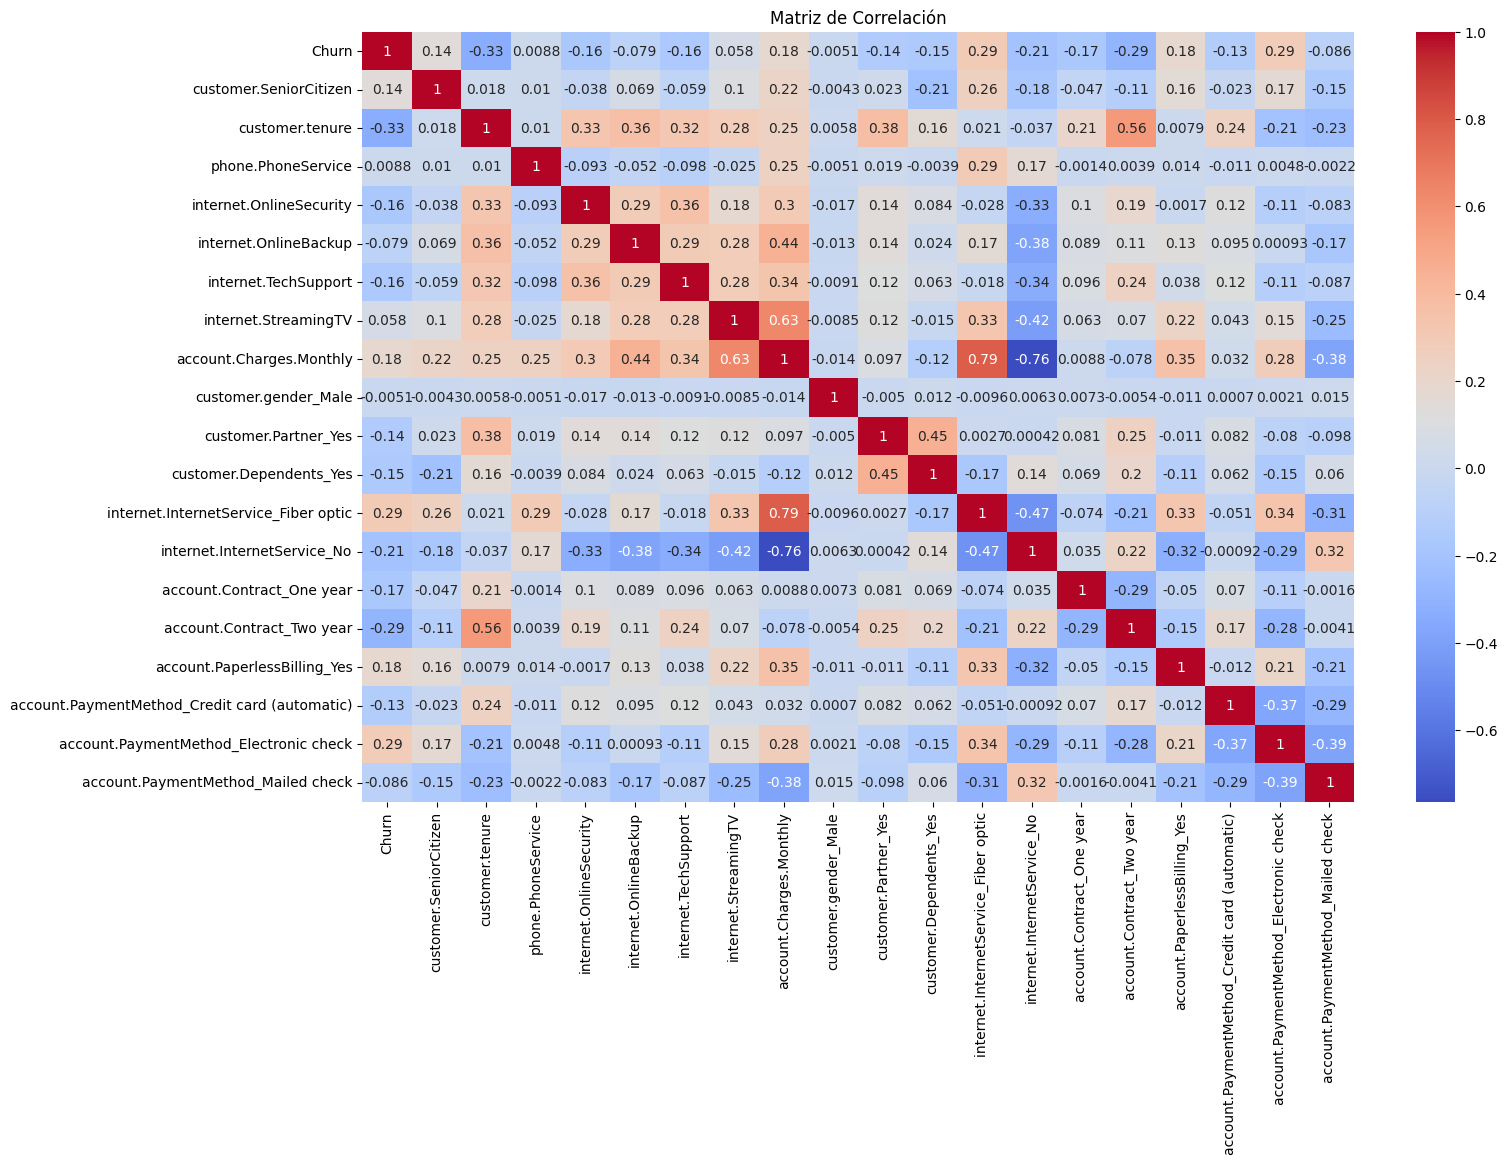

In [244]:
correlacion = datos_encoded.corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 10))
sns.heatmap(correlacion, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

In [245]:
# VARIABLES CORRELACIONADAS
# customer.tenure, internet.InternetService, account.Contract, account.PaymentMethod

### Análisis Dirigido

Descripción

Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [246]:
import plotly.express as px
import plotly.graph_objects as go
px.box(datos, x = 'customer.tenure', color = 'Churn', width=700, height=350, title='Tiempo de Contrato x Cancelación')

In [247]:
px.box(datos, x = 'account.Charges.Monthly', color = 'Churn', width=700, height=350, title='Cargo Mensual x Cancelación')

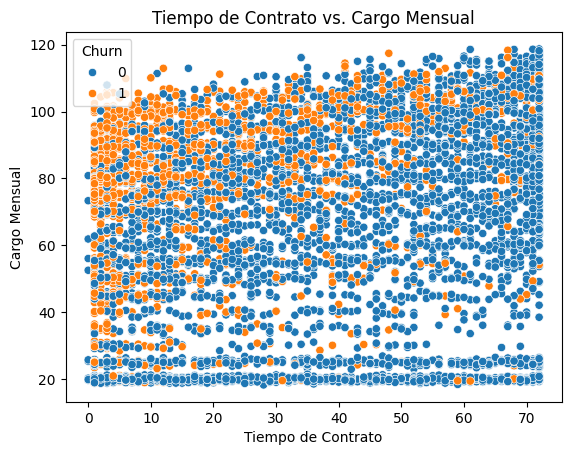

In [248]:
sns.scatterplot(data=datos, x='customer.tenure', y='account.Charges.Monthly', hue='Churn')
plt.title('Tiempo de Contrato vs. Cargo Mensual')
plt.xlabel('Tiempo de Contrato')
plt.ylabel('Cargo Mensual')
plt.show()


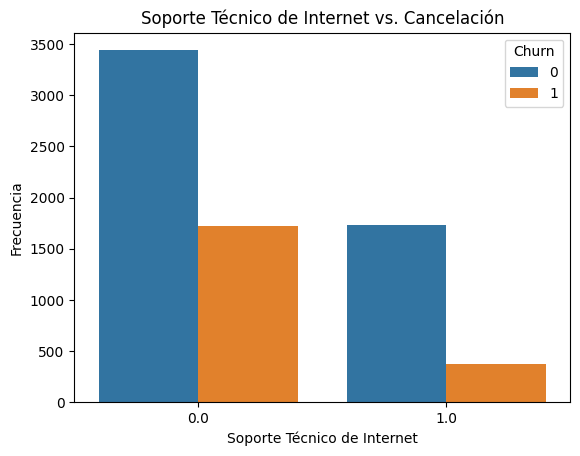

In [249]:
sns.countplot(data=datos, x='internet.TechSupport', hue='Churn')
plt.title('Soporte Técnico de Internet vs. Cancelación')
plt.xlabel('Soporte Técnico de Internet')
plt.ylabel('Frecuencia')
plt.show()

### Separación de Datos

Descripción

Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

In [250]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

###Creación de Modelos

Descripción

Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.

In [251]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

knn = KNeighborsClassifier()
knn.fit(X_balanceada_normalizada, y_balanceada)

KNeighborsClassifier()

In [252]:
X_test_normalizado = normalizacion.transform(X_test)
knn.score(X_test_normalizado, y_test)

0.7847317744154058

In [253]:
modelo_arbol = DecisionTreeClassifier(max_depth=None, random_state =42)
modelo_arbol.fit(X_balanceada, y_balanceada)

DecisionTreeClassifier(random_state=42)

In [254]:
modelo_arbol.predict(X_test)

array([0, 0, 0, ..., 1, 1, 0])

In [255]:
modelo_arbol.score(X_test, y_test)

0.9071526822558459

In [256]:
modelo_arbol.score(X_balanceada, y_balanceada)
#modelo sobreentrenado

0.9875

In [257]:
print(f'Exactitud Dummy: {dummy.score(X_test, y_test)}')
print(f'Exactitud modelo_arbol: {modelo_arbol.score(X_test, y_test)}')
print(f'Exactitud KNN: {knn.score(X_test_normalizado, y_test)}')

Exactitud Dummy: 0.7132049518569463
Exactitud modelo_arbol: 0.9071526822558459
Exactitud KNN: 0.7847317744154058


###Evaluación de los Modelos

Descripción

Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)
Precisión
Recall
F1-score
Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.

In [258]:
y_pred = knn.predict(X_test_normalizado)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy}")
print(f"KNN F1 Score: {f1}")
print(f"KNN Precision: {precision}")
print(f"KNN Recall: {recall}")

KNN Accuracy: 0.7847317744154058
KNN F1 Score: 0.6680805938494168
KNN Precision: 0.5988593155893536
KNN Recall: 0.7553956834532374


In [259]:
y_pred = modelo_arbol.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy}")
print(f"Decision Tree F1 Score: {f1}")
print(f"Decision Tree Precision: {precision}")
print(f"Decision Tree Recall: {recall}")

#El modelo de arbol está con overfitting sin profundidad del Decision Tree, se procederá a aplicar max_depth=5; al momento el mejor modelo es KNN.

Decision Tree Accuracy: 0.9071526822558459
Decision Tree F1 Score: 0.8367593712212817
Decision Tree Precision: 0.8439024390243902
Decision Tree Recall: 0.829736211031175


In [260]:
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state =42)
modelo_arbol.fit(X_balanceada, y_balanceada)
modelo_arbol.score(X_test, y_test)

0.7489683631361761

In [261]:
y_pred = modelo_arbol.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy}")
print(f"Decision Tree F1 Score: {f1}")
print(f"Decision Tree Precision: {precision}")
print(f"Decision Tree Recall: {recall}")

Decision Tree Accuracy: 0.7489683631361761
Decision Tree F1 Score: 0.6019629225736096
Decision Tree Precision: 0.552
Decision Tree Recall: 0.6618705035971223


In [262]:
print(f'Exactitud Dummy: {dummy.score(X_test, y_test)}')
print(f'Exactitud KNN: {knn.score(X_test_normalizado, y_test)}')
print(f'Exactitud modelo_arbol: {modelo_arbol.score(X_test, y_test)}')

Exactitud Dummy: 0.7132049518569463
Exactitud KNN: 0.7847317744154058
Exactitud modelo_arbol: 0.7489683631361761




---


---

El modelo de arbol mejoró considerablemente posterior al reajuste, cesando en generalizar la data y equiparando sus scores a un nivel consistente e incluso r2superando al modelo KNN.


---



###Análisis de la Importancia de las Variables

Descripción

Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

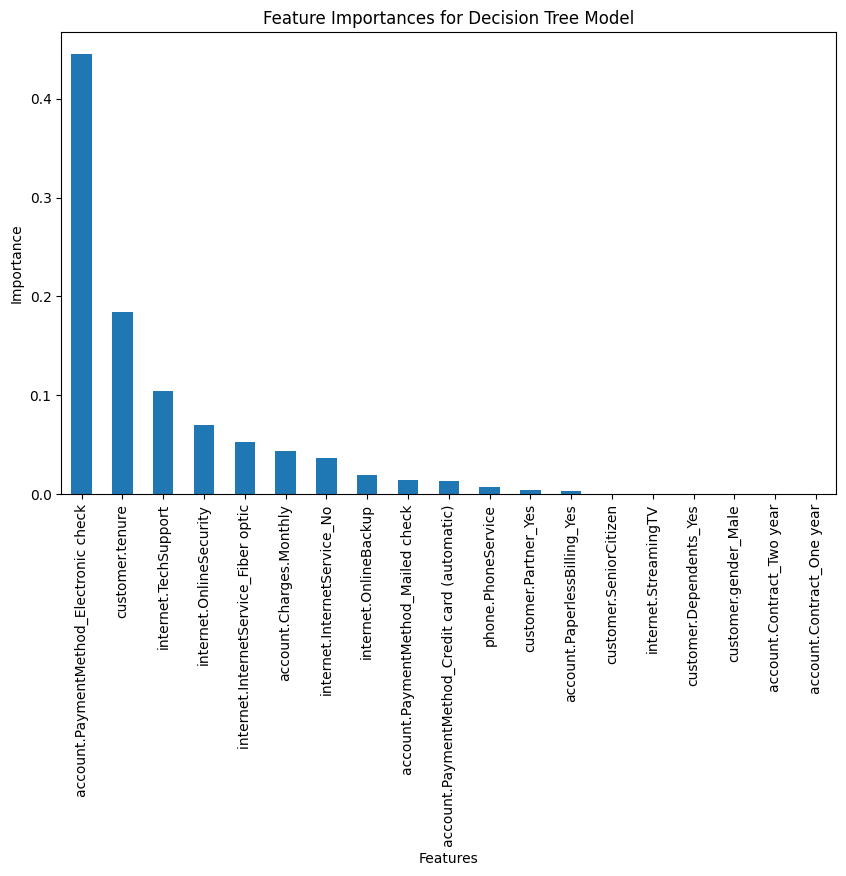

In [263]:
feature_importances = modelo_arbol.feature_importances_
feature_names = X_balanceada.columns
importance_series = pd.Series(feature_importances, index=feature_names)
sorted_importance = importance_series.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sorted_importance.plot(kind='bar')
plt.title('Feature Importances for Decision Tree Model')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.show()

In [264]:
display(sorted_importance)

,0
account.PaymentMethod_Electronic check,0.445022
customer.tenure,0.184586
internet.TechSupport,0.103918
internet.OnlineSecurity,0.069903
internet.InternetService_Fiber optic,0.052817
account.Charges.Monthly,0.044030
internet.InternetService_No,0.036980
internet.OnlineBackup,0.019273
account.PaymentMethod_Mailed check,0.014511
account.PaymentMethod_Credit card (automatic),0.013013


In [265]:
from sklearn.dummy import DummyRegressor
baseline = DummyRegressor()
baseline.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_dummy = baseline.predict(X_test)

def calcular_regresion(y_test, y_pred):
  rmse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)

  metricas = {
      'RMSE': round(rmse**(1/2),4),
      'MAE': round(mae,4),
      'R2': round(r2,4)
  }

  return metricas

In [266]:
resultados_baseline = calcular_regresion(y_test, y_pred_dummy)
resultados_baseline

{'RMSE': 0.4523, 'MAE': 0.4097, 'R2': -0.0}

In [267]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_balanceada, y_balanceada)
ypred = modelo_arbol.predict(X_test)
cm = confusion_matrix(y_test, ypred)
print("Confusion Matrix:")
display(cm)

Confusion Matrix:


array([[813, 224],
       [141, 276]])




---


---
De acuerdo a lo expuesto por KNN y DT, las variables relacionadas al contrato mes a mes, mantención en el tiempo del cliente sumado a internet de fibra óptica, generan los atributos de mayor consideración por el modelo.

Lo confirmamos en la última matriz de confusión en la cual aumentamos la cantidad de verdaderos negativos.

Posteriormente en la conclusión será detallado el análisis holístico del proceso completo y sus highlights.

---



### Conclusión

Descripción

Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

###INFORME

a.- Luego de la extracción del dataset, se procedió a realizar la limpieza correspondiente además del tratado de datos NaN o Null permitiendo su proceso a la etapa siguiente.

b.- Se visualizaron gráficos para la comprensión global de la data relacionado a los objetivos del procesamiento de la data, en este caso, la cancelación de los clientes en la compañía de telecomunicaciones telecomX;
como por ejemplo, la matriz de correlación donde pudimos identificar las variables principales las cuales comandarían gran parte del procesamiento de la data por modelar. Posterior a esto realizamos el OneHotEncoding con las variables categóricas.

c.- Al identificar las proporciones de data en cuanto a la cancelación de clientela fue necesario realizar un balanceo de clases mediante la función SMOTE de "imblearn.over_sampling"; como también la normalización de data para el eventual entrenamiento del modelo KNN.

d.- Luego del entrenamiento de modelos pudimos encontrar a un modelo KNN como superior en casi todos los aspectos, pero debido a que el modelo de arbol no fue profundizado; posterior a esta correción el modelo de árbol superó considerablemente al KNN incluso el baseline.

d.- En el análisis dirigido fue posible visualizar los puntos más importantes con respecto a la cancelación de clientes, las cuales deberán ser consideradas por quienes ostenten el presente proyecto; donde pudimos identificar previo al "feature_engineering" los siguientes puntos:

  1. Cancelación por tipo de contrato: Mientras menor sea el estilo de contrato que se acuerda con el cliente, mayor probabilidad de cancelación existe, los contratos mes a mes resaltaron una y otra vez en todos los modelos como uno de los principales predictores de cancelación.
  
  2.- Aunque a su vez, esto se correlaciona con la duración del cliente, "tenure"; el cual indica la cantidad de meses que llevan con la compañía, mientras mayor es el tiempo, disminuye considerablemente la cancelación. Por lo tanto, la estrategia en este aspecto es retener lo más posible en el tiempo a la clientela, como por ejemplo, beneficios que se vayan desbloqueando en el tiempo, lo cual genera un incentivo al mantenerse como cliente en la compañía.

  3.- Los cargos mensuales también aparecieron una y otra vez, aunque considerada una variable obvia en el sentido de cancelaciones, el aspecto de interés para el receptor del siguiente informe, es que mientras mayor sea la carga mensual facilita la cancelación, se menciona debido a que en este punto es difícil analizar con poca data, pero se debería revisar el porqué se le permite en primer lugar a estos clientes alcanzar altas cargas monetarias mes a mes en cuanto a facturación; cabe revisar las políticas internas de la empresa para ahondar en ese aspecto. Como por ejemplo, permitir contratar numerosos servicios solo después de cierta cantidad de meses como cliente de la empresa.

  4.- La fibra óptica apareció como una de las variables sorpresa del proceso, mientras mayor sea el uso, mayor propensión a cancelar indican los datos. Lo cual se relaciona al punto anterior y la carga de facturación mes a mes, ya que es uno de los servicios de mayor costo actualmente en varios países.

  5.- Finalmente, aspecto a considerar por la empresa, es el uso de soporte técnico, las personas que cancelan tienen un menor uso de soporte; punto interesante a analizar por el área comercial si consideran disminución del valor a ofrecer por este servicio o facilitarlo aún más podrían ejecutar una mantención más efectiva de clientela.

En conclusión, fueron identificadas variables considerables y fueron presentadas estrategias de analizar superficial en sus inicios y posterior a la acumulación de data ya mayormente dirigida será posible realizar impactos de mayor profundidad para la solucion o en su defecto mitigación del problema inicialmente planteado.


